## Read output files

In [1]:
import awkward as ak
import numpy as np
import uproot
import os
import pandas as pd

In [2]:

"""
'2016APV': {
    'data': '../condor/output/data/2016APV/SinglePhoton/',
    'ZJetsToQQ': '../condor/output/mc/2016APV/ZJetsToQQ/',
    'WJetsToQQ': '../condor/output/mc/2016APV/WJetsToQQ/',
    'TTGJets': '../condor/output/mc/2016APV/TTGJets/',
    'QCD': '../condor/output/mc/2016APV/QCD',
    'GJets': '../condor/output/mc/2016APV/GJets',
    'ZpToHGamma_M1000': '../condor/output/mc/2016APV/ZpToHGamma/ZpToHGamma_M1000/',
    'ZpToHGamma_M2000': '../condor/output/mc/2016APV/ZpToHGamma/ZpToHGamma_M2000/',
    'ZpToHGamma_M3000': '../condor/output/mc/2016APV/ZpToHGamma/ZpToHGamma_M3000/',
},
'2016': {
    'data': '../condor/output/data/2016/SinglePhoton/',
    'ZJetsToQQ': '../condor/output/mc/2016/ZJetsToQQ/',
    'WJetsToQQ': '../condor/output/mc/2016/WJetsToQQ/',
    'TTGJets': '../condor/output/mc/2016/TTGJets/',
    'QCD': '../condor/output/mc/2016/QCD',
    'GJets': '../condor/output/mc/2016/GJets',
    'ZpToHGamma_M1000': '../condor/output/mc/2016/ZpToHGamma/ZpToHGamma_M1000/',
    'ZpToHGamma_M2000': '../condor/output/mc/2016/ZpToHGamma/ZpToHGamma_M2000/',
    'ZpToHGamma_M3000': '../condor/output/mc/2016/ZpToHGamma/ZpToHGamma_M3000/',
},
'2017': {
    'data': '../condor/output/data/2017/SinglePhoton/',
    'ZJetsToQQ': '../condor/output/mc/2017/ZJetsToQQ/',
    'WJetsToQQ': '../condor/output/mc/2017/WJetsToQQ/',
    'TTGJets': '../condor/output/mc/2017/TTGJets/',
    'QCD': '../condor/output/mc/2017/QCD',
    'GJets': '../condor/output/mc/2017/GJets',
    'ZpToHGamma_M1000': '../condor/output/mc/2017/ZpToHGamma/ZpToHGamma_M1000/',
    'ZpToHGamma_M2000': '../condor/output/mc/2017/ZpToHGamma/ZpToHGamma_M2000/',
    'ZpToHGamma_M3000': '../condor/output/mc/2017/ZpToHGamma/ZpToHGamma_M3000/',
},"""
basedir = {
    '2018': {
        'data': '../condor/output/data/2018/EGamma/',
        'TTJets': '../condor/output/mc/2018/TTJets/',
        'TTGJets': '../condor/output/mc/2018/TTGJets/',
        'ZJetsToNuNu': '../condor/output/mc/2018/ZJetsToNuNu/',
        'ZJetsToQQ': '../condor/output/mc/2018/ZJetsToQQ/',
        'ZGToJJG': '../condor/output/mc/2018/ZGToJJG/',
        'WJetsToLNu': '../condor/output/mc/2018/WJetsToLNu/',
        'WJetsToQQ': '../condor/output/mc/2018/WJetsToQQ/',
        'WGToJJG': '../condor/output/mc/2018/WGToJJG/',
        'QCD': '../condor/output/mc/2018/QCD/',
        'GJets': '../condor/output/mc/2018/GJets/',
        #'ZpToHGamma_M1000': '../condor/output/mc/2018/ZpToHGamma/ZpToHGamma_M1000/',
        'Zp(2TeV)ToHG': '../condor/output/mc/2018/ZpToHG/ZpToHGamma_M2000/',
        #'ZpToHGamma_M3000': '../condor/output/mc/2018/ZpToHGamma/ZpToHGamma_M3000/',
        #'ZpToHGamma': '../condor/output/mc/2018/ZpToHGamma/',
    },
}
BKG = set([i for i in basedir['2018'].keys() if not (i.startswith('Zp') or i=='data')])

filepath={year: {c: [] for c in basedir[year]} for year in basedir}
for year in basedir:
    for c in basedir[year]:
        for (current_path, dirs, files) in os.walk(basedir[year][c]):
            for f in files:
                if f.endswith('.parq'):
                    filepath[year][c].append(os.path.join(current_path, f))

filepath

{'2018': {'data': ['../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-37.parq',
   '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-42.parq',
   '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-30.parq',
   '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-14.parq',
   '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-67.parq',
   '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-18.parq',
   '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-31.parq',
   '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-2.parq',
   '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-19.parq',
   '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-6.parq',
   '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-0.parq',
   '../condor/output/data/2018/EGamma/EGamma_Run2018B/data_2018_EGamma-49.parq',
   '../condor/o

In [19]:
BKG = set([i for i in basedir['2018'].keys() if not (i.startswith('Zp') or i=='data')])

In [6]:
events = {year: {k: [] for k in filepath[year]} for year in filepath}
for year in filepath:
    for k, v in filepath[year].items():
        for f in v:
            if os.path.getsize(f) == 0:
                print('Zero size:', f)
                continue
            if len(pd.read_parquet(f))==0:
                continue
            array = ak.from_parquet(f)
            if len(array)>0:
                events[year][k].append(array)
        if len(events[year][k]) > 0:
            events[year][k] = ak.concatenate(events[year][k], axis=0)

#del events['2016APV']['ZpToHGamma_M1000'], events['2016APV']['ZpToHGamma_M2000'], events['2016APV']['ZpToHGamma_M3000']
#del events['2016']['ZpToHGamma_M1000'], events['2016']['ZpToHGamma_M2000'], events['2016']['ZpToHGamma_M3000']
events

Zero size: ../condor/output/mc/2018/TTJets/TTJets/mc_2018_TTJets-222.parq
Zero size: ../condor/output/mc/2018/TTJets/TTJets/mc_2018_TTJets-345.parq
Zero size: ../condor/output/mc/2018/TTJets/TTJets/mc_2018_TTJets-323.parq
Zero size: ../condor/output/mc/2018/TTJets/TTJets/mc_2018_TTJets-317.parq
Zero size: ../condor/output/mc/2018/ZJetsToNuNu/ZJetsToNuNu_HT-400To600/mc_2018_ZJetsToNuNu-1.parq
Zero size: ../condor/output/mc/2018/ZJetsToNuNu/ZJetsToNuNu_HT-400To600/mc_2018_ZJetsToNuNu-15.parq
Zero size: ../condor/output/mc/2018/ZJetsToNuNu/ZJetsToNuNu_HT-400To600/mc_2018_ZJetsToNuNu-19.parq
Zero size: ../condor/output/mc/2018/ZJetsToNuNu/ZJetsToNuNu_HT-400To600/mc_2018_ZJetsToNuNu-0.parq
Zero size: ../condor/output/mc/2018/ZJetsToNuNu/ZJetsToNuNu_HT-400To600/mc_2018_ZJetsToNuNu-13.parq
Zero size: ../condor/output/mc/2018/ZJetsToNuNu/ZJetsToNuNu_HT-400To600/mc_2018_ZJetsToNuNu-2.parq
Zero size: ../condor/output/mc/2018/ZJetsToNuNu/ZJetsToNuNu_HT-400To600/mc_2018_ZJetsToNuNu-7.parq
Zero siz

{'2018': {'data': <Array [{AK8jet_eta: -0.603, ... ] type='500552 * union[union[union[union[union[...'>,
  'TTJets': <Array [{AK8jet_eta: 0.667, ... ] type='1129 * union[union[union[union[union[uni...'>,
  'TTGJets': <Array [{AK8jet_eta: 1.53, ... ] type='9764 * union[union[union[union[union[unio...'>,
  'ZJetsToNuNu': <Array [{AK8jet_pt: 326, ... ] type='1066 * union[union[union[union[union[union[...'>,
  'ZJetsToQQ': <Array [{AK8jet_eta: 0.673, ... ] type='1542 * union[union[union[union[union[uni...'>,
  'ZGToJJG': <Array [{AK8jet_phi: -0.0619, ... ] type='56833 * union[{"AK8jet_phi": ?float32,...'>,
  'WJetsToLNu': <Array [{AK8jet_eta: 0.438, ... ] type='35451 * union[union[union[union[union[un...'>,
  'WJetsToQQ': <Array [{AK8jet_phi: -1.96, ... ] type='6483 * union[union[union[union[union[uni...'>,
  'WGToJJG': <Array [{AK8jet_eta: 2.22, ... ] type='122079 * union[union[{"AK8jet_eta": ?floa...'>,
  'QCD': <Array [{AK8jet_eta: -0.609, ... ] type='11538 * union[union[union[union[uni

In [7]:
for y in events:
    for i in events[y]:
        if i=='data' or len(events[y][i])==0:
            continue
        print(y, i, set(events[y][i].event_weight), sep='\t')

2018	TTJets	{0.41262777643698834, -0.41262777643698834}
2018	TTGJets	{0.10555055737495422, -0.10555055737495422}
2018	ZJetsToNuNu	{0.024186961352825165, 0.047525398433208466, 0.030095942318439484, 0.03914002329111099, 0.0012531501706689596}
2018	ZJetsToQQ	{0.12603111565113068, 0.11741647124290466, 0.4904776391671956}
2018	ZGToJJG	{-0.08643259853124619, 0.08643259853124619}
2018	WJetsToLNu	{0.010707801207900047, 0.3636884093284607, 0.34474447610976555, 0.08503110706806183, 0.00022820790763944387, 0.04039609432220459}
2018	WJetsToQQ	{0.27540484070777893, 1.772090724902408, 0.1322723627090454}
2018	WGToJJG	{0.09761133044958115, -0.09761133044958115}
2018	QCD	{0.2132134586572647, 0.5812569246921679, 4.2895717444221395, 8.907606249990467, 29.894587570928675, 349.90607214469446}
2018	GJets	{0.9128381388278342, 16.295155962245435, 2.1023192052524484, 0.31825571551452514}
2018	Zp(2TeV)ToHG	{0.0004985833656974137}


## Decomposite signal

In [8]:
def decomposite(signal: ak.Array):
    HWW_decay_mode = ak.fill_none(signal['gen_HWW_decay_mode'], 0)

    for tag in set(signal.fields):
        if tag.startswith('gen_Zp') and tag!='gen_ZpToHGamma':
            signal[tag.split('_')[1]] = signal[signal[tag]]
    
    signal['HWW_4q'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode >= 32)
    ]
    
    signal['HWW_qqlv'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode > 16) &
        (HWW_decay_mode < 32)
    ]
    
    signal['HWW_lvlv'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode <= 16)
    ]
    
    return signal

DECOMPOSITE = False
if DECOMPOSITE:
    for y in events:
        for c in events[y]:
            if c.startswith('ZpToHGamma'):
                events[y].update({c: decomposite(events[y][c])})
events

{'2018': {'data': <Array [{AK8jet_eta: -0.603, ... ] type='500552 * union[union[union[union[union[...'>,
  'TTJets': <Array [{AK8jet_eta: 0.667, ... ] type='1129 * union[union[union[union[union[uni...'>,
  'TTGJets': <Array [{AK8jet_eta: 1.53, ... ] type='9764 * union[union[union[union[union[unio...'>,
  'ZJetsToNuNu': <Array [{AK8jet_pt: 326, ... ] type='1066 * union[union[union[union[union[union[...'>,
  'ZJetsToQQ': <Array [{AK8jet_eta: 0.673, ... ] type='1542 * union[union[union[union[union[uni...'>,
  'ZGToJJG': <Array [{AK8jet_phi: -0.0619, ... ] type='56833 * union[{"AK8jet_phi": ?float32,...'>,
  'WJetsToLNu': <Array [{AK8jet_eta: 0.438, ... ] type='35451 * union[union[union[union[union[un...'>,
  'WJetsToQQ': <Array [{AK8jet_phi: -1.96, ... ] type='6483 * union[union[union[union[union[uni...'>,
  'WGToJJG': <Array [{AK8jet_eta: 2.22, ... ] type='122079 * union[union[{"AK8jet_eta": ?floa...'>,
  'QCD': <Array [{AK8jet_eta: -0.609, ... ] type='11538 * union[union[union[union[uni

## Start plotting

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

def flow(hist: bh.Histogram, overflow: bool=True, underflow: bool=False):
    h, var = hist.view(flow=(overflow | underflow)).value, hist.view(flow=(overflow | underflow)).variance
    if overflow: ## h, var also include underflow bins but in plots usually no underflow data
        ## And we've filled None with -999, so we shouldn't show underflow data (mostly from filled None)
        h[-2]+=h[-1]; var[-2]+=var[-1]
    if underflow:
        h[1]+=h[0]; var[1]+=var[0]
    if overflow or underflow:
        h = h[1:-1]; var = var[1:-1]
    return h, var

weight={y: {c: events[y][c].event_weight for c in events[y] if c!='data'} for y in events}

In [10]:
def data_compare_plot(arrays, plot_name: str, x_name: str, cuts=None, bins=40, x_min=0, x_max=3000, density=True, overflow=True, underflow=False):
    bin_width = (x_max-x_min)/bins
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}
    ## canvas initializing
    # colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    # f, ax = plt.subplots()
    f = plt.figure(figsize=(9, 9))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=True, ax=ax, fontsize=18)
    
    ## analyze

        
    ## plot
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=['red', 'blue', 'green', 'darkorange', 'cyan', 'HotPink', 'darkviolet', 'SlateGray', 'black', 'LightSkyBlue'])
    for (k, v) in arrays.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        hist.fill(v)
        h, var = flow(hist=hist, overflow=overflow, underflow=underflow)
        hep.histplot(h, bins=hist.axes[0].edges, xerr=bin_width/2, yerr=np.sqrt(var), label=k, histtype='step', density=density, stack=False, ax=ax, linewidth=2)
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 

    ## axises
    ax.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax.set_xlim(x_min, x_max)
    if 'eta' in plot_name:
        ax.set_ylim(1e-2, ax.get_ylim()[1]*5)
    else:
        ax.set_ylim(1e-8, ax.get_ylim()[1]*5)
    ax.set_yscale('log')
    #ax.ticklabel_format(useOffset=False, style='scientific')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        ax.set_ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        ax.set_ylabel('A.U.', fontsize=20, ha='right', y=1)

    plt.xticks(size=16)
    plt.yticks(size=16)

    ## title, text and legend
    # plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    ax.legend(loc="best", ncol=2, frameon=False, fontsize=18)
    # plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')

    ## finalizing
    suffix = '_AU' if density else ''
    if not os.path.exists('./plots'):
        os.makedirs('./plots')
    plt.savefig(f"./plots/data_compare_{plot_name}{suffix}.pdf", bbox_inches='tight')
    plt.show()

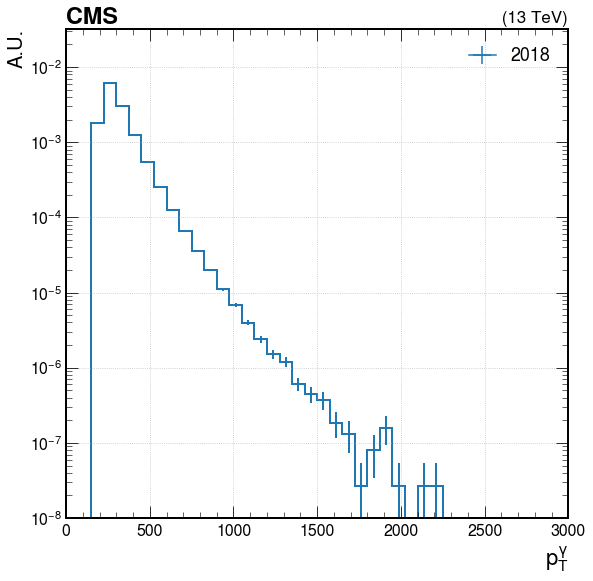

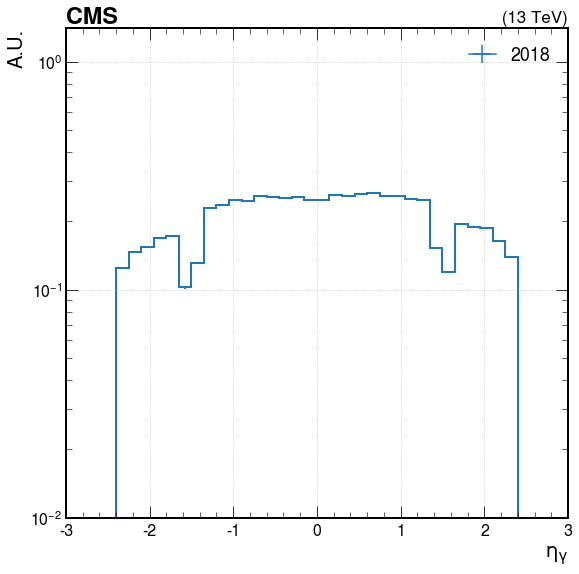

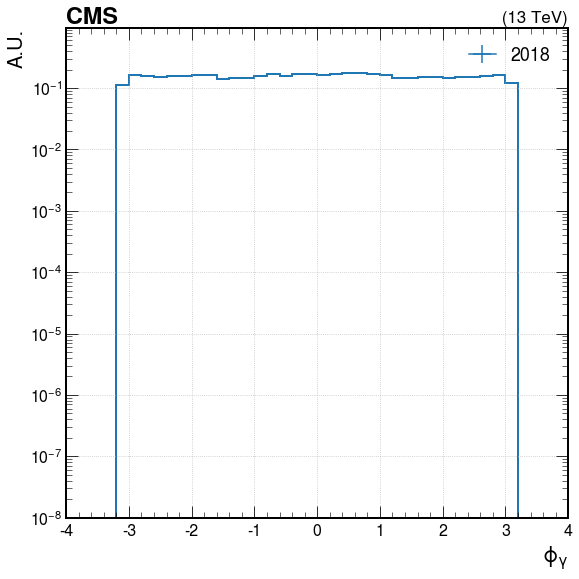

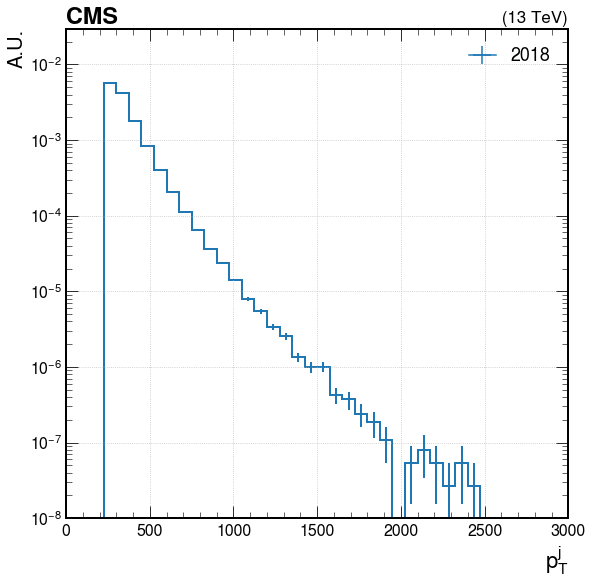

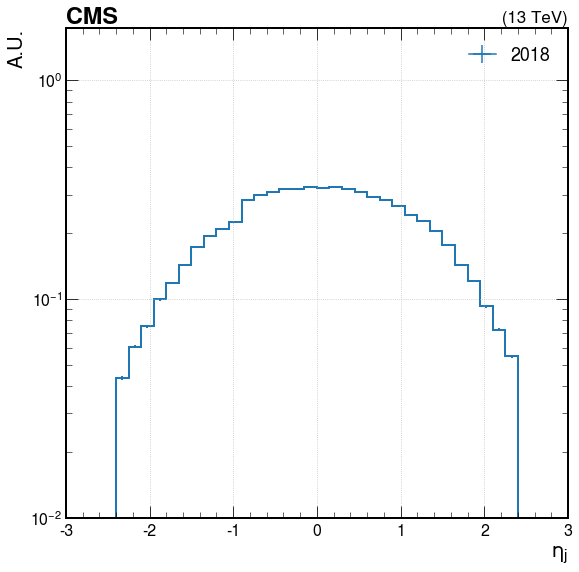

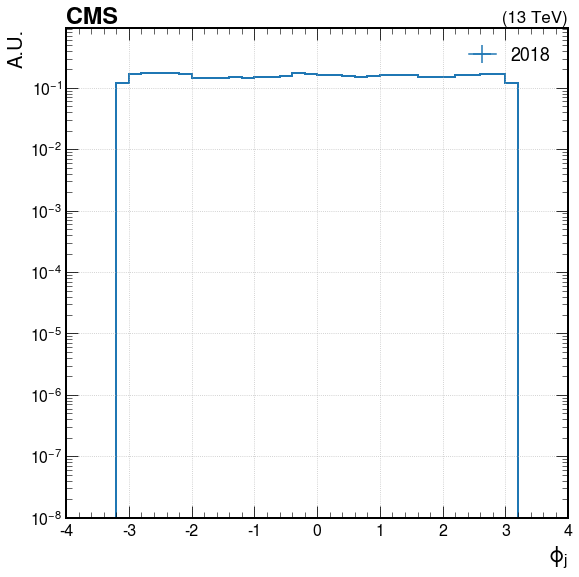

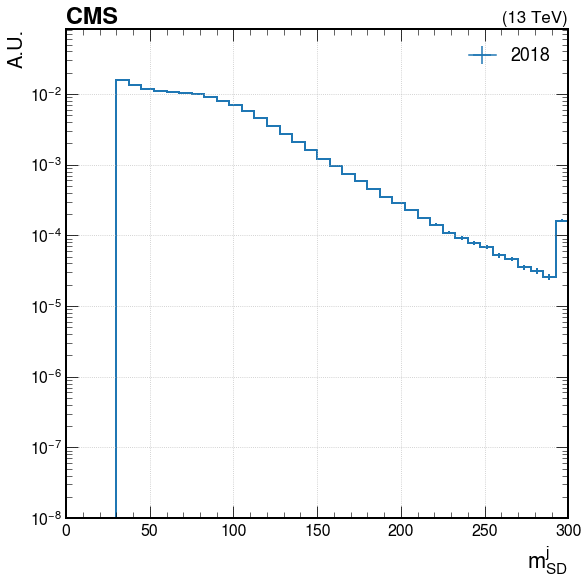

In [11]:
arrays={k: events[k]['data'].photon_pt for k in events}
data_compare_plot(arrays, 'photon_pt', x_name=r'$p_T^{\gamma}$')

arrays={k: events[k]['data'].photon_eta for k in events}
data_compare_plot(arrays, 'photon_eta', x_name=r'$\eta_{\gamma}$', x_min=-3, x_max=3)

arrays={k: events[k]['data'].photon_phi for k in events}
data_compare_plot(arrays, 'photon_phi', x_name=r'$\phi_\gamma$', x_min=-4, x_max=4)

arrays={k: events[k]['data'].AK8jet_pt for k in events}
data_compare_plot(arrays, 'AK8jet_pt', x_name=r'$p_T^j$')

arrays={k: events[k]['data'].AK8jet_eta for k in events}
data_compare_plot(arrays, 'AK8jet_eta', x_name=r'$\eta_j$', x_min=-3, x_max=3)

arrays={k: events[k]['data'].AK8jet_phi for k in events}
data_compare_plot(arrays, 'AK8jet_phi', x_name=r'$\phi_j$', x_min=-4, x_max=4)

arrays={k: events[k]['data'].AK8jet_msoftdrop for k in events}
data_compare_plot(arrays, 'AK8jet_msoftdrop', x_name=r'$m_{SD}^j$', x_min=0, x_max=300)

In [ ]:
def data_mc_compare_plot(arrays, weight, plot_name: str, x_name: str, cuts=None, year='2018', bins=40, x_min=0, x_max=2000, density=False, overflow=True, underflow=False, fraction_log=False):
    LUMI = {"2016APV": 19.52, "2016": 16.81, "2017": 41.48, "2018": 59.83,}
    bin_width = (x_max-x_min)/bins
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}
        
    ## canvas initializing
    # f, ax = plt.subplots()
    f = plt.figure(figsize=(9, 10))
    gs = mpl.gridspec.GridSpec(3, 1, height_ratios=[5, 1, 1], hspace=0.1)
    ax = f.add_subplot(gs[0])
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=True, year=year.replace('APV', ''), ax=ax, lumi=LUMI[year], fontsize=18)
    ## Ratio panel
    ax1 = f.add_subplot(gs[1])
    ax2 = f.add_subplot(gs[2])
    ax1.grid()
    ax2.grid()
    
    ## analyze
    stacked = {'h': {}, 'var': {}}
    individual = {'h': {}, 'var': {}}
    
    for (k,v) in arrays.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        if 'delta_phi' in plot_name:
            values = np.min([v, 2*np.pi-v], axis=0)
        values = ak.fill_none(v, -999)
        
        if k!='data' and weight is not None:
            hist.fill(values, weight=weight[k])
        else:
            hist.fill(values)
        #print('before', len(hist.view(flow=(overflow | underflow)).value), hist.view(flow=(overflow | underflow).value))
        h, var = flow(hist=hist, overflow=overflow, underflow=underflow)
        #print('after', len(h), h)
        if k in BKG: 
            stacked['h'][k] = h
            stacked['var'][k] = var
        else:
            individual['h'][k] = h
            individual['var'][k] = var
        
    ## plot
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=['darkorange', 'cyan', 'HotPink', 'darkviolet', 'SlateGray', 'black', 'LightSkyBlue'])
    SIG_COLOR={'Zp(1TeV)ToHG': 'blue', 'Zp(2TeV)ToHG': 'red', 'Zp(3TeV)ToHG': 'green', 'ZpToH(WW)Gamma_M1000': 'blue', 'ZpToH(WW)Gamma_M2000': 'red', 'ZpToH(WW)Gamma_M3000': 'green'}
    ax1.plot([x_min,x_max], [1,1], color='black', linestyle='dashed')
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too)
    if len(stacked['h'].keys())>0:
        hep.histplot(list(stacked['h'].values()), bins=hist.axes[0].edges, label=list(stacked['h'].keys()), histtype='fill', density=density, stack=True, linewidth=2, ax=ax)
        bkg_h = np.sum(list(stacked['h'].values()), axis=0)
        bkg_var = np.sum(list(stacked['var'].values()), axis=0)
    for (k,v) in individual['h'].items():
        if k=='data':
            hep.histplot(v, bins=hist.axes[0].edges, yerr=np.sqrt(individual['var'][k]), label=k, color='black', histtype='errorbar', density=density, stack=False, ax=ax)
            hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')
        else:  # signal
            hep.histplot(v, bins=hist.axes[0].edges, yerr=np.sqrt(individual['var'][k]), label=k, histtype='step', density=density, stack=False, linewidth=2, ax=ax, color=SIG_COLOR[k])
            y = v / np.sqrt(bkg_h + 1)
            hep.histplot(y, bins=hist.axes[0].edges, label=k, histtype='step', density=density, stack=False, ax=ax2, color=SIG_COLOR[k])

    ## axises
    ax.set_xlim(x_min, x_max)
    #ax.set_xticklabels([])
    ax.set_ylim(0.01 if not density else 0, ax.get_ylim()[1]*(6e2 if not density else 1.2))
    if not density:
        ax.set_yscale('log')
    #ax.ticklabel_format(useOffset=False, style='scientific')
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='x', which='major', labelsize=0)
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        ax.set_ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        ax.set_ylabel('A.U.', fontsize=20, ha='right', y=1)
    
    ax1.set_xlim(x_min, x_max)
    ax1.set_xticklabels([])
    if fraction_log:
        ax1.set_ylim(1e-1, 1e1)
        ax1.set_yscale('log')
    else:
        ax1.set_ylim(0, 3)
    ax1.set_ylabel(r'$\frac{Data}{bkg\ MC}$', ha='center', fontsize=24)
    #ax1.ticklabel_format(useOffset=False, style='plain')
    ax1.tick_params(axis='both', which='major', labelsize=16)
    
    #ax2.set_yscale('log')
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(0, 1)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax2.set_ylabel(r'$S/\sqrt{B+1}$', ha='center', fontsize=16)
    ax2.ticklabel_format(useOffset=False, style='plain')
    ax2.tick_params(axis='both', which='major', labelsize=16)

    plt.xticks(size=16)
    plt.yticks(size=16)

    ## title, text and legend
    # plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    ax.legend(loc="best", ncol=3, frameon=False, fontsize=15)
    # plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')

    ## finalizing
    suffix = '_AU' if density else ''
    if not os.path.exists('./plots'):
        os.makedirs('./plots')
    plt.savefig(f"./plots/{year}_{plot_name}{suffix}.pdf", bbox_inches='tight')
    plt.show()

In [37]:
print(events.keys())
print(events['2018']['data'].fields)

dict_keys(['2018'])
['AK8jet_eta', 'AK8jet_msoftdrop', 'AK8jet_pt', 'AK8jet_phi', 'AK8jet_mass', 'photon_pt', 'photon_eta', 'photon_phi', 'photon_mass', 'b-jet_pt', 'b-jet_eta', 'b-jet_phi', 'b-jet_mass', 'event_MET_pt', 'event_genWeight', 'event_event', 'photon-jet_pt', 'photon-jet_eta', 'photon-jet_phi', 'photon-jet_mass', 'photon-jet_deltaR']


In [38]:
#y = '2018'
#arrays={k: ak.flatten(events[y][k].gen_Zp_mass, axis=1) for k in events[y] if k.startswith('ZpToHGamma')}
#data_mc_compare_plot(arrays, plot_name='gen_Zp_mass', x_name=r'$m^{gen}_{Zp}$', x_max=4000, x_min=0, bins=100, weight=None, year=y, log=False)

ValueError: spans must have compatible lengths

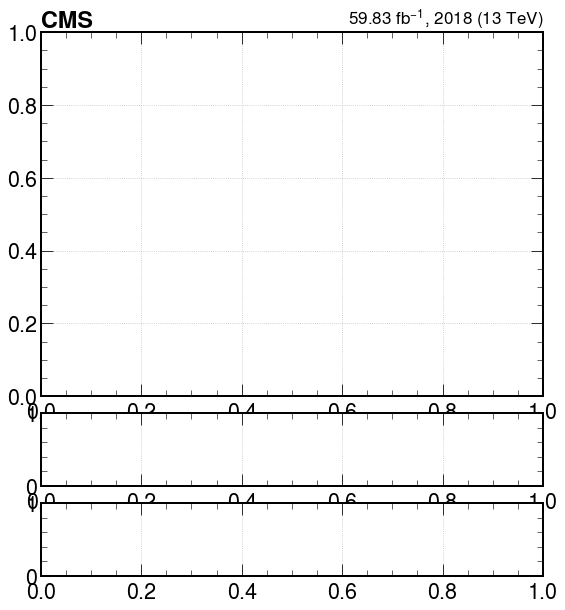

In [39]:
for y in events:
    if y!='2018':
        continue
    arrays={k: events[y][k].photon_pt for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon_pt', x_name=r'$p_T^{\gamma}$', x_max=3000, x_min=0, bins=100, weight=weight[y], year=y)
    arrays={k: events[y][k].photon_eta for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon_eta', x_name=r'$\eta_{\gamma}$', x_max=3, x_min=-3, bins=120, weight=weight[y], year=y)
    arrays={k: events[y][k].photon_phi for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon_phi', x_name=r'$\phi_{\gamma}$', x_max=4, x_min=-4, bins=120, weight=weight[y], year=y)
    arrays={k: events[y][k].AK8jet_pt for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='AK8jet_pt', x_name=r'$p_T^{j}$', x_max=3000, x_min=0, bins=60, weight=weight[y], year=y)
    arrays={k: events[y][k].AK8jet_eta for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='AK8jet_eta', x_name=r'$\eta_j$', x_max=3, x_min=-3, bins=120, weight=weight[y], year=y)
    arrays={k: events[y][k].AK8jet_phi for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='AK8jet_phi', x_name=r'$\phi_j$', x_max=4, x_min=-4, bins=120, weight=weight[y], year=y)
    arrays={k: events[y][k].AK8jet_msoftdrop for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='AK8jet_msoftdrop', x_name=r'$m_{SD}^{j}$', x_max=300, x_min=30, bins=27, weight=weight[y], year=y)

/tmp/dfu/ipykernel_22036/229111553.py:57: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


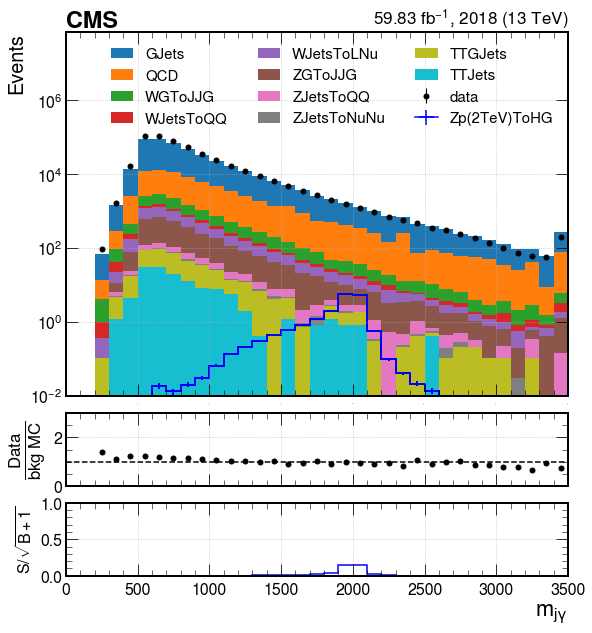

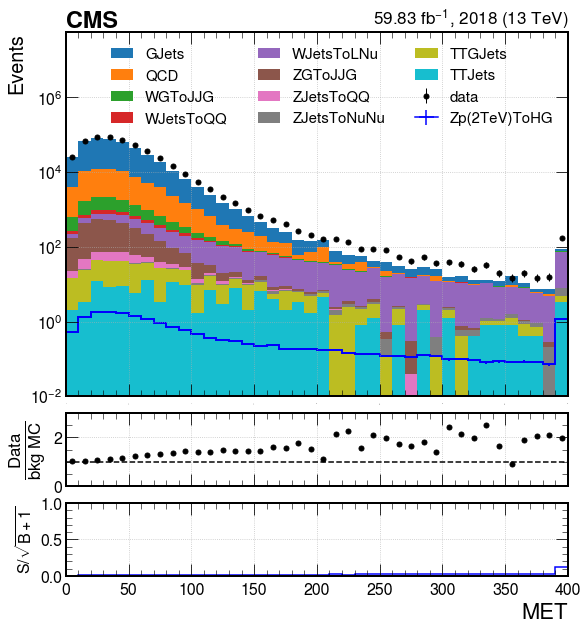

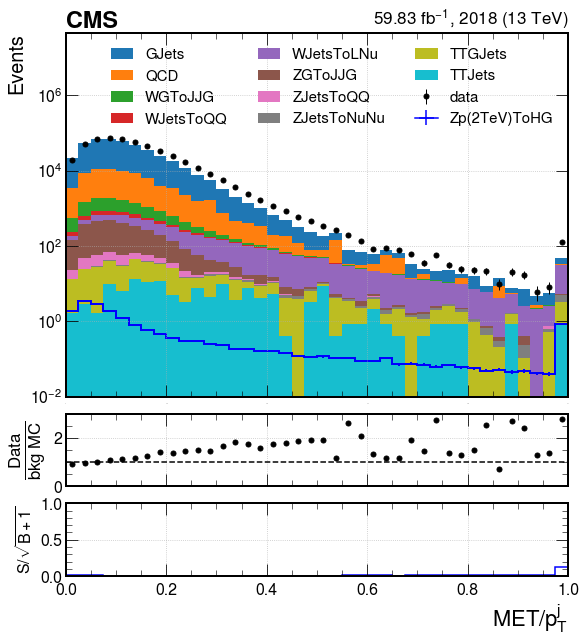

In [ ]:
for y in events:
    if y!='2018':
        continue
    arrays={k: events[y][k]['photon-jet_mass'] for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon-jet_mass', x_name=r'$m_{j\gamma}$', x_max=3500, bins=35, weight=weight[y], year=y)
    arrays={k: events[y][k]['event_MET_pt'] for k in events[y]}
    data_mc_compare_plot(arrays, x_name='MET', plot_name='event_MET_pt', x_max=400, bins=40, weight=weight[y], year=y, fraction_log=False)
    arrays={k: events[y][k].event_MET_pt/events[y][k].AK8jet_pt for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='MET_over_AK8jet_pt', x_name=r'$MET/p_T^{j}$', x_max=1, x_min=0, bins=40, weight=weight[y], year=y, fraction_log=False)

/tmp/dfu/ipykernel_22036/229111553.py:57: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


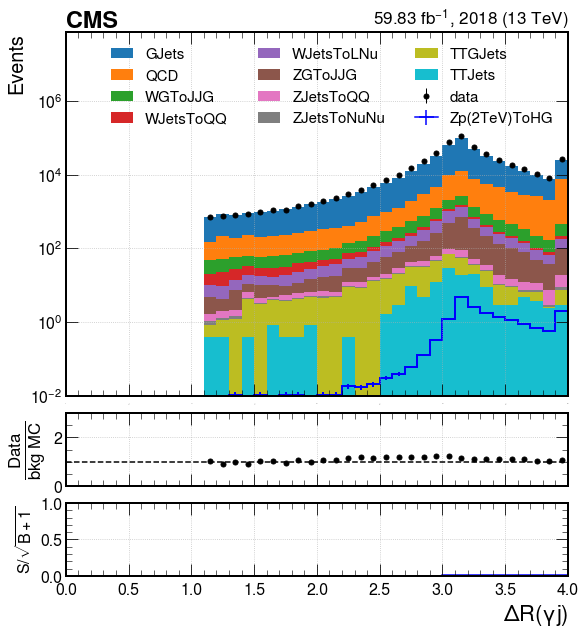

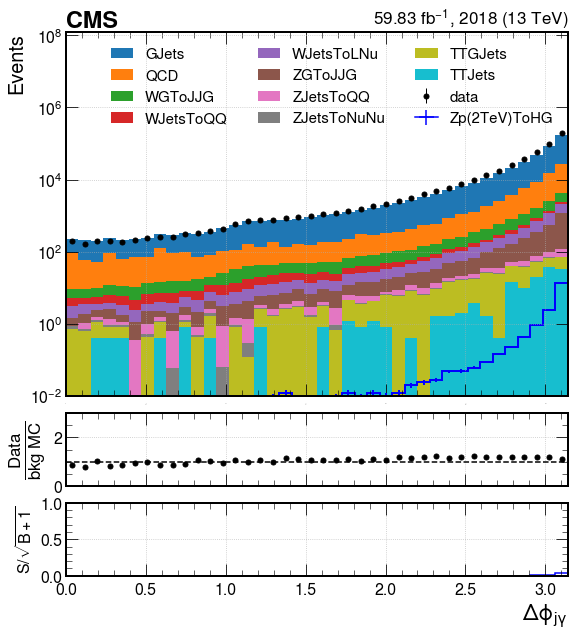

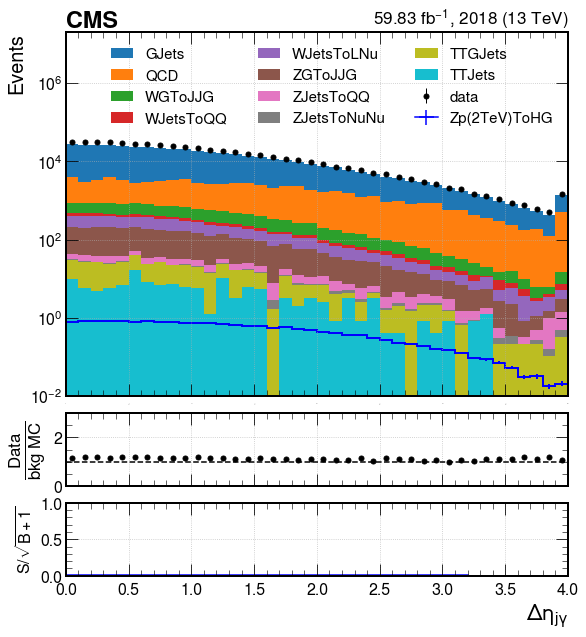

/tmp/dfu/ipykernel_22036/229111553.py:57: RuntimeWarning: invalid value encountered in true_divide
  hep.histplot(individual['h']['data'] / bkg_h, bins=hist.axes[0].edges, histtype='errorbar', density=density, stack=False, ax=ax1, color='black')


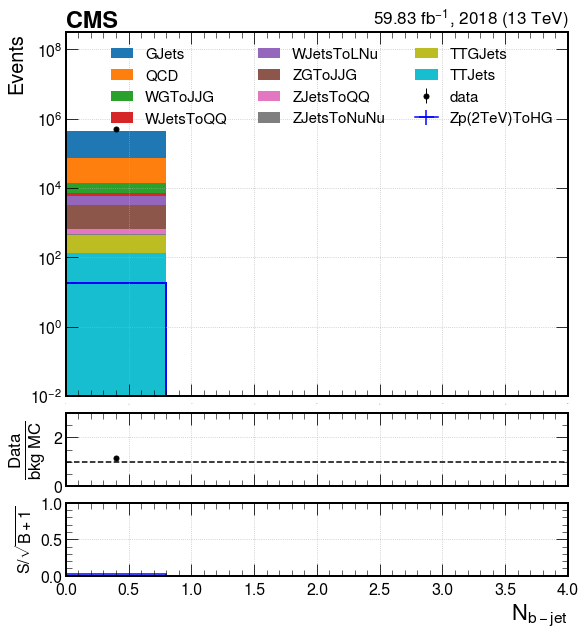

In [ ]:
for y in events:
    if y!='2018':
        continue
    arrays={k: events[y][k]['photon-jet_deltaR'] for k in events[y]}
    data_mc_compare_plot(arrays, x_name=r'$\Delta R(\gamma j)$', plot_name='photon-jet_deltaR', x_max=4, bins=40, weight=weight[y], year=y)
    arrays={k: np.min([abs(events[y][k].photon_phi - events[y][k].AK8jet_phi), 2*np.pi - abs(events[y][k].photon_phi - events[y][k].AK8jet_phi)], axis=0) for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon-jet_delta_phi', x_name=r'$\Delta\phi_{j\gamma}$', x_max=np.pi, x_min=0, bins=40, weight=weight[y], year=y)
    arrays={k: abs(events[y][k].photon_eta - events[y][k].AK8jet_eta) for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='photon-jet_delta_eta', x_name=r'$\Delta\eta_{j\gamma}$', x_max=4, x_min=0, bins=40, weight=weight[y], year=y)
    arrays={k: ak.num(events[y][k]['b-jet_pt'], axis=1) for k in events[y]}
    data_mc_compare_plot(arrays, plot_name='num_b-jet', x_name=r'$N_{b-jet}$', x_max=4, x_min=0, bins=5, weight=weight[y], year=y)

In [ ]:
arrays = {k: events['2018'][k]['photon-jet_mass'] for k in events['2018']}
for k in set(arrays.keys()):
    if k.startswith('Zp'):
        arrays[k.replace('HG', 'H(WW)G')] = arrays[k][
            events['2018'][k]['gen_ZpToH(WW)Gamma'] & 
            (events['2018'][k].event_MET_pt/events['2018'][k].AK8jet_pt > 0.6)
        ]
        weight['2018'].update({
            k.replace('HG', 'H(WW)G'): events['2018'][k].event_weight[
                events['2018'][k]['gen_ZpToH(WW)Gamma'] & 
                (events['2018'][k].event_MET_pt/events['2018'][k].AK8jet_pt > 0.6)
            ]
        })
        del arrays[k]
    else:
        arrays[k] = arrays[k][
            (events['2018'][k].event_MET_pt/events['2018'][k].AK8jet_pt > 0.6)
        ]
        if k=='data':
            continue
        weight['2018'].update({
            k: events['2018'][k].event_weight[
                (events['2018'][k].event_MET_pt/events['2018'][k].AK8jet_pt > 0.6)
            ]
        })
        
        
arrays

{'data': <Array [1.43e+03, 982, 602, ... 769, 791, 826] type='698 * ?float32'>,
 'TTJets': <Array [377, 574, 500, ... 902, 1.17e+03, 739] type='57 * ?float32'>,
 'TTGJets': <Array [828, 681, 910, ... 721, 1.07e+03, 905] type='483 * ?float32'>,
 'ZJetsToNuNu': <Array [753, 932, 1.02e+03, ... 670, 1.85e+03] type='204 * ?float32'>,
 'ZJetsToQQ': <Array [765, 708, 541] type='3 * ?float32'>,
 'ZGToJJG': <Array [623, 883, 824, ... 1.08e+03, 660, 449] type='43 * ?float32'>,
 'WJetsToLNu': <Array [1.59e+03, 3.23e+03, ... 780, 1.01e+03] type='3281 * ?float32'>,
 'WJetsToQQ': <Array [1.26e+03, 535, ... 1.05e+03, 1.21e+03] type='7 * ?float32'>,
 'WGToJJG': <Array [570, 339, 577, 502, ... 947, 582, 694] type='62 * ?float32'>,
 'QCD': <Array [506, 522, 593, 817, ... 833, 849, 604] type='29 * ?float32'>,
 'GJets': <Array [857, 871, 571, ... 654, 1.04e+03, 627] type='357 * ?float32'>,
 'Zp(2TeV)ToH(WW)G': <Array [1.61e+03, 1.53e+03, ... 1.37e+03] type='1919 * ?float32'>}

In [40]:
weight

{'2018': {'TTJets': <Array [-0.413, -0.413, ... 0.413, -0.413] type='57 * ?float64'>,
  'TTGJets': <Array [0.106, 0.106, 0.106, ... -0.106, 0.106] type='483 * ?float32'>,
  'ZJetsToNuNu': <Array [0.0242, 0.0242, ... 0.0301, 0.0301] type='204 * ?float32'>,
  'ZJetsToQQ': <Array [0.126, 0.117, 0.117] type='3 * ?float64'>,
  'ZGToJJG': <Array [0.0864, 0.0864, ... 0.0864, 0.0864] type='43 * ?float32'>,
  'WJetsToLNu': <Array [0.0107, 0.0107, ... 0.0404, 0.0404] type='3281 * ?float64'>,
  'WJetsToQQ': <Array [0.132, 0.132, 0.132, ... 0.132, 0.132] type='7 * ?float64'>,
  'WGToJJG': <Array [0.0976, 0.0976, ... -0.0976, 0.0976] type='62 * ?float32'>,
  'QCD': <Array [4.29, 4.29, 4.29, ... 0.581, 0.581] type='29 * ?float64'>,
  'GJets': <Array [0.913, 0.913, 0.913, ... 0.318, 0.318] type='357 * ?float64'>,
  'Zp(2TeV)ToHG': <Array [0.000499, 0.000499, ... 0.000499] type='1919 * ?float32'>}}

ValueError: spans must have compatible lengths

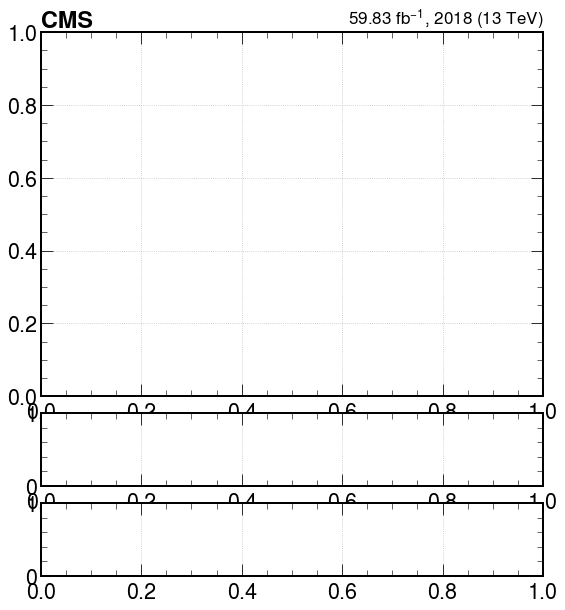

In [41]:
data_mc_compare_plot(arrays, plot_name='high_MET_photon-jet_mass', x_name=r'$m_{j\gamma}$', x_max=3500, bins=35, weight=weight['2018'], year='2018', density=False)
data_mc_compare_plot(arrays, plot_name='high_MET_photon-jet_mass', x_name=r'$m_{j\gamma}$', x_max=3500, bins=35, weight=weight['2018'], year='2018', density=True)